In [20]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [21]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [22]:
import numpy as np #numerical analysis
import pandas as pd # process in a dataframe

import matplotlib.pyplot as plt #plotting graph
import seaborn as sns # advance ploting

import matplotlib.image as  mpimg # image processing
from sklearn.model_selection import train_test_split # train test split
from sklearn.metrics import confusion_matrix, classification_report # model performance metrics
from tensorflow.keras.utils import to_categorical # utility function
from tensorflow.keras.models import Sequential # sequental model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout #layers

#import keras.optimizers import RMSprop
#from keras.preprocessing.image import ImageDataGenerator
#from keras.callbacks import ReduceLROnPlateau

In [39]:
train = pd.read_csv('/content/sample_data/train.csv')
test = pd.read_csv('/content/sample_data/test.csv')

# check first
print(train.isna().sum().sum(), "NaNs in train")
print(test.isna().sum().sum(), "NaNs in test")

# then fix — pixel NaNs almost always just mean "no ink there" = 0
train = train.fillna(0)
test = test.fillna(0)

160 NaNs in train
369 NaNs in test


In [40]:
train.describe()


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,8597.000000,8597.0,8597.0,8597.0,8597.0,8597.0,8597.0,8597.0,8597.0,8597.0,...,8597.000000,8597.000000,8597.000000,8597.0,8597.0,8597.0,8597.0,8597.0,8597.0,8597.0
mean,4.442247,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.157729,0.117715,0.019774,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,2.889234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.548090,4.826068,1.434819,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,253.000000,130.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
train['label'].value_counts().sort_index()

,count
label,
0,855
1,944
2,905
3,860
4,835
5,777
6,854
7,889
8,818


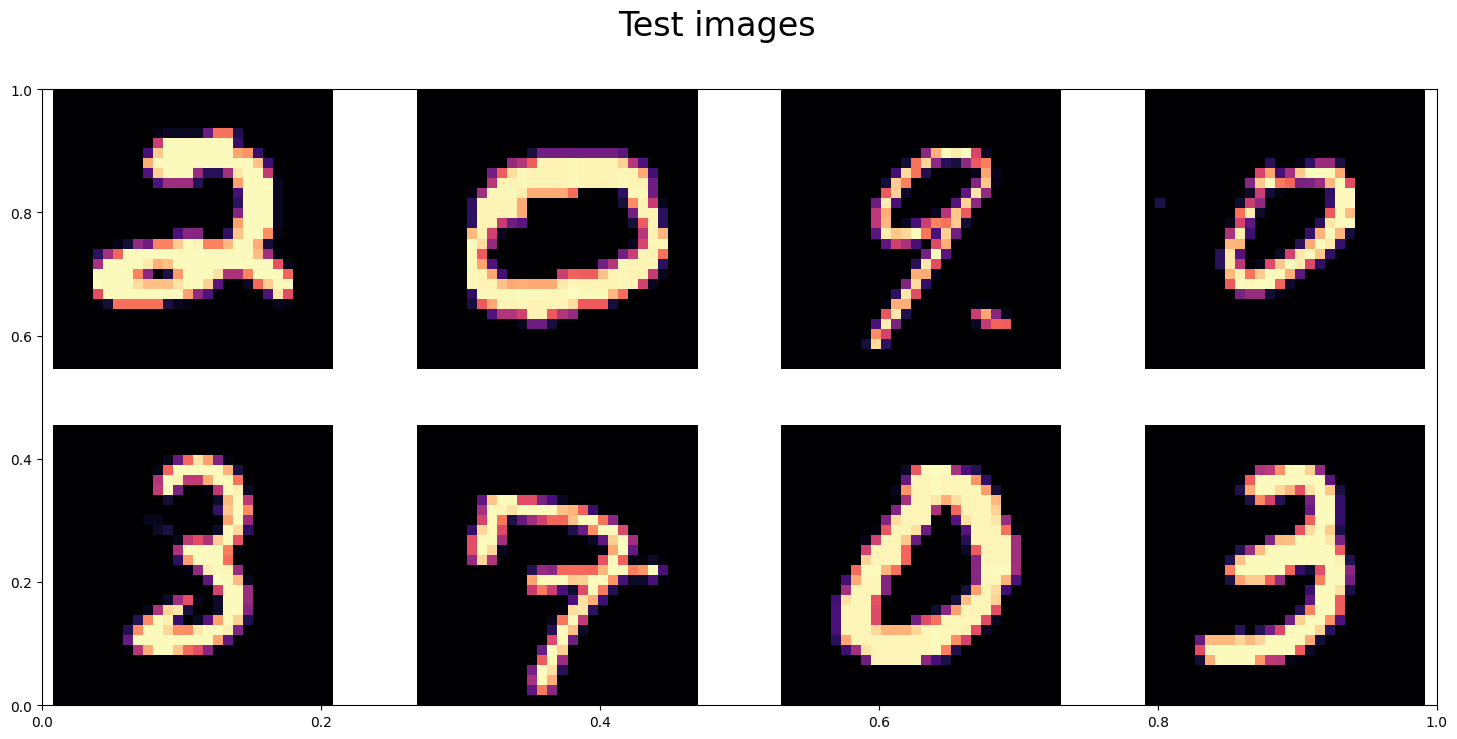

In [42]:
fig,ax = plt.subplots(figsize=(18, 8))
for ind, row in test.iloc[:8, :].iterrows():
    plt.subplot(2,4, ind+1)
    img = row.to_numpy()[:].reshape(28, 28)
    fig.suptitle('Test images', fontsize=24)
    plt.axis('off')
    plt.imshow(img, cmap='magma')

In [43]:
X = train.drop('label', axis=1).values
y = train['label'].values

X_test = test.values

In [44]:
X = X / 255.0
X_test = X_test / 255.0

In [45]:
X = X.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [46]:
print(X.shape)


(8597, 28, 28, 1)


In [47]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (6877, 28, 28, 1)
X_val shape: (1720, 28, 28, 1)
y_train shape: (6877,)
y_val shape: (1720,)


In [48]:
y_train = to_categorical(y_train, num_classes=10)
y_val = to_categorical(y_val, num_classes=10)

print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

y_train shape: (6877, 10)
y_val shape: (1720, 10)


In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [50]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.7242 - loss: 0.8619 - val_accuracy: 0.9302 - val_loss: 0.2222
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.9081 - loss: 0.3025 - val_accuracy: 0.9593 - val_loss: 0.1339
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9405 - loss: 0.2026 - val_accuracy: 0.9616 - val_loss: 0.1066
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.9497 - loss: 0.1584 - val_accuracy: 0.9698 - val_loss: 0.0944
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.9609 - loss: 0.1319 - val_accuracy: 0.9674 - val_loss: 0.0919
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9682 - loss: 0.1106 - val_accuracy: 0.9651 - val_loss: 0.0972
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.9715 - loss: 0.0992 - val_accuracy: 0.9738 - val_loss: 0.0851
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9699 - loss: 0.0915 - val_ac

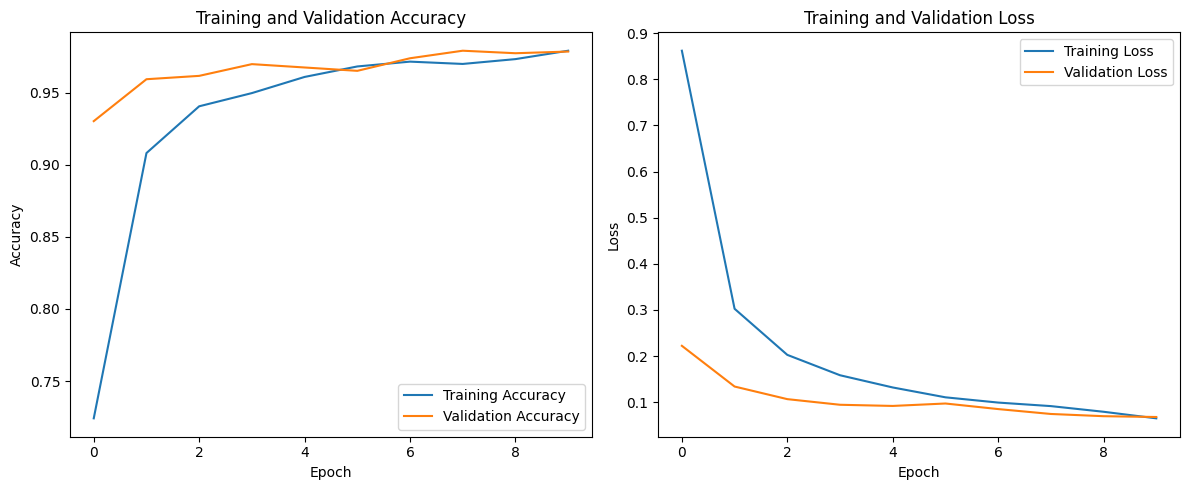

In [53]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [54]:
from sklearn.metrics import classification_report

# get predictions on validation set
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)  # y_val is one-hot, convert back

print(classification_report(y_true, y_pred))

54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       165
           1       0.99      1.00      0.99       203
           2       0.98      0.97      0.97       189
           3       0.99      0.98      0.98       165
           4       0.95      1.00      0.98       158
           5       0.99      0.97      0.98       157
           6       0.98      0.99      0.98       159
           7       0.96      0.98      0.97       172
           8       0.99      0.95      0.97       177
           9       0.98      0.96      0.97       175

    accuracy                           0.98      1720
   macro avg       0.98      0.98      0.98      1720
weighted avg       0.98      0.98      0.98      1720



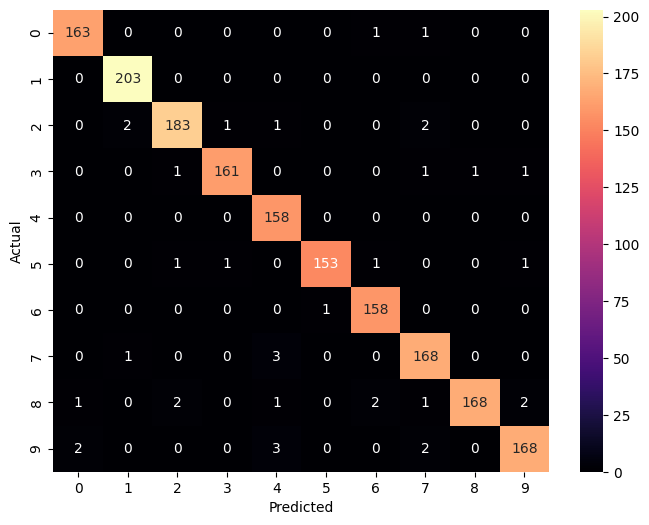

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()